In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [69]:
X_test = np.load('../data/processed/X_test_XGB.npy')
y_test = np.load('../data/processed/y_test.npy')
X_val = np.load('../data/processed/X_val.npy')
y_val = np.load('../data/processed/y_val.npy')
X_train = np.load('../data/processed/X_train.npy')
y_train = np.load('../data/processed/y_train.npy')

In [70]:
import xgboost as xgb

dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test, label=y_test)

total_fraude = int(y_train.sum())
total_normal = int(len(y_train) - total_fraude)
anomalias_porcentaje = total_fraude / len(y_train)
print(f'Total fraude: {total_fraude}, Total normal: {total_normal}, Porcentaje de anomalias: {anomalias_porcentaje*100:.6f} %')


Total fraude: 394, Total normal: 227451, Porcentaje de anomalias: 0.172925 %


In [71]:
params = {
    'objective': 'binary:logistic',  
    'eval_metric': 'aucpr',
    'scale_pos_weight': total_normal / total_fraude,
    'max_depth': 6,
    'learning_rate': 0.1
}

In [72]:
evals = [(dtrain, 'train'), (dval, 'validation')]

model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=evals,
    early_stopping_rounds=50
)

[0]	train-aucpr:0.56370	validation-aucpr:0.50880
[1]	train-aucpr:0.57356	validation-aucpr:0.51835
[2]	train-aucpr:0.60063	validation-aucpr:0.52941
[3]	train-aucpr:0.60571	validation-aucpr:0.53087
[4]	train-aucpr:0.62220	validation-aucpr:0.55073
[5]	train-aucpr:0.61860	validation-aucpr:0.55180
[6]	train-aucpr:0.61991	validation-aucpr:0.55087
[7]	train-aucpr:0.62180	validation-aucpr:0.54861
[8]	train-aucpr:0.71983	validation-aucpr:0.62806
[9]	train-aucpr:0.72095	validation-aucpr:0.62662
[10]	train-aucpr:0.73428	validation-aucpr:0.62864
[11]	train-aucpr:0.73763	validation-aucpr:0.63006
[12]	train-aucpr:0.82927	validation-aucpr:0.69000
[13]	train-aucpr:0.83117	validation-aucpr:0.69076
[14]	train-aucpr:0.83389	validation-aucpr:0.69012
[15]	train-aucpr:0.83761	validation-aucpr:0.69102
[16]	train-aucpr:0.85857	validation-aucpr:0.71729
[17]	train-aucpr:0.86068	validation-aucpr:0.71654
[18]	train-aucpr:0.86254	validation-aucpr:0.71601
[19]	train-aucpr:0.86576	validation-aucpr:0.71691
[20]	train

In [73]:
probabilidades = model.predict(dtest) # devualve probabilidades de la clase positiva

predicciones = [1 if prob >= 0.5 else 0 for prob in probabilidades]

print(predicciones)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

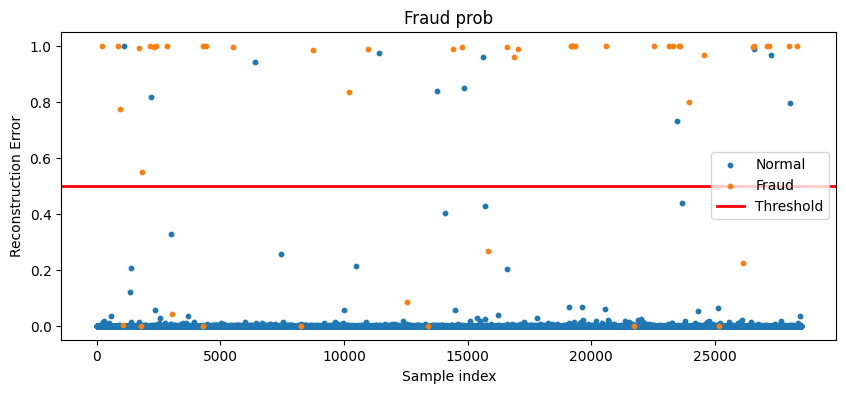

In [74]:
import pandas as pd

error_df = pd.DataFrame({
    "prob": probabilidades,  # salida del XGB
    "true_class": y_test  # 0/1
})

groups = error_df.groupby("true_class")
fig, ax = plt.subplots(figsize=(10,4))

# Graficamos los puntos
for name, group in groups:
    ax.scatter(
        group.index,
        group.prob,
        s = 10,
        label="Fraud" if name == 1 else "Normal"
    )

# Graficamos la frontera de decisión
ax.axhline(0.5, color='r', linewidth=2, label='Threshold')

ax.set_title("Fraud prob")
ax.set_xlabel("Sample index")
ax.set_ylabel("Reconstruction Error")
ax.legend()
plt.show()

In [75]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, predicciones))

print("Matriz de Confusión:")
print(confusion_matrix(y_test, predicciones))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.78      0.78      0.78        49

    accuracy                           1.00     28481
   macro avg       0.89      0.89      0.89     28481
weighted avg       1.00      1.00      1.00     28481

Matriz de Confusión:
[[28421    11]
 [   11    38]]


In [86]:
tn, fp, fn, tp = confusion_matrix(y_test, predicciones).ravel()

precision = tp / (tp + fp)
recall = tp / (tp + fn)
print("Precision:", precision)
print("Recall:", recall)

Precision: 0.7755102040816326
Recall: 0.7755102040816326


AUCPR: 0.8046232651762699


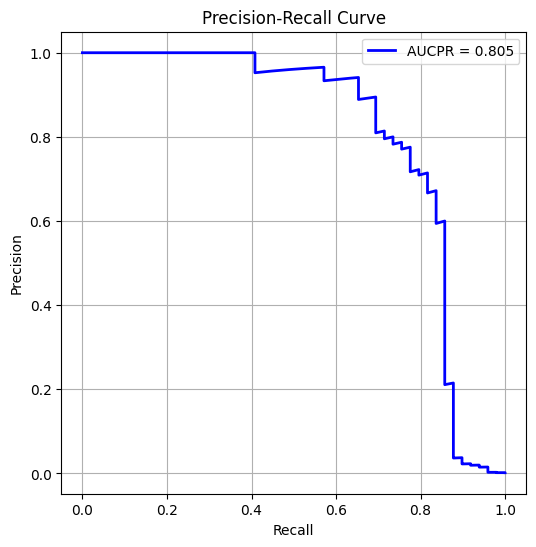

In [77]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
# PR-AUC
precision, recall, thresholds = precision_recall_curve(y_test, probabilidades)
aucpr = average_precision_score(y_test, probabilidades)
print("AUCPR:", aucpr)
plt.figure(figsize=(6,6))
plt.plot(recall, precision, color='b', lw=2, label=f'AUCPR = {aucpr:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()


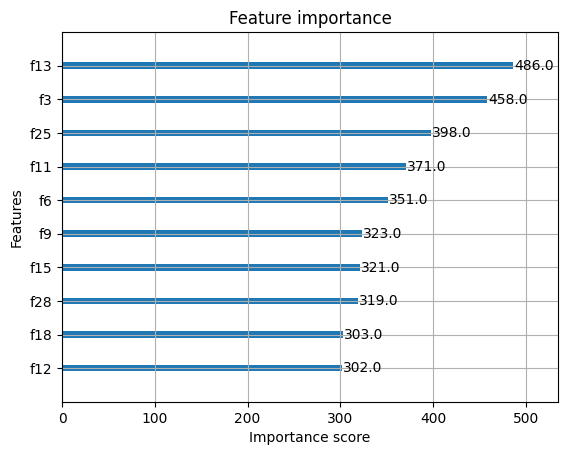

In [78]:
import matplotlib.pyplot as plt

# Graficar las variables más importantes
xgb.plot_importance(model, max_num_features=10) # Mostramos las 10 mejores
plt.show()

### Con la salida del AE como feature

In [79]:
import sys
import os

project_root = os.path.abspath("..")
sys.path.append(project_root)

In [ ]:
from src.autoencoder import Autoencoder, get_reconstruction_error

ae = Autoencoder(input_dim=29)

In [80]:
import torch

# Cargamos el autoencoder ya entrenado
ae.load_state_dict(torch.load("autoencoder.pth"))


<All keys matched successfully>

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

X_train_AE = np.load('../data/processed/X_train_AE.npy')
X_val_AE = np.load('../data/processed/X_val_AE.npy')
X_test_AE = np.load('../data/processed/X_test_AE.npy')

X_train_tensor = torch.FloatTensor(X_train_AE)
X_val_tensor = torch.FloatTensor(X_val_AE)
X_test_tensor = torch.FloatTensor(X_test_AE)

recon_error_train = get_reconstruction_error(ae, X_train_tensor)
recon_error_val = get_reconstruction_error(ae, X_val_tensor)
recon_error_test = get_reconstruction_error(ae, X_test_tensor)

# Escalamos los datos de reconstruccion del AE
scaler = StandardScaler()
recon_error_train_scaled = scaler.fit_transform(recon_error_train.reshape(-1,1))
recon_error_test_scaled = scaler.transform(recon_error_test.reshape(-1,1))
recon_error_val_scaled = scaler.transform(recon_error_val.reshape(-1,1))

In [82]:
X_train_feature = np.concatenate([X_train, recon_error_train_scaled.reshape(-1,1)], axis=1)
X_val_feature = np.concatenate([X_val, recon_error_val_scaled.reshape(-1,1)], axis=1)
X_test_feature = np.concatenate([X_test, recon_error_test_scaled.reshape(-1,1)], axis=1)

dtrain_AE = xgb.DMatrix(X_train_feature, label=y_train)
dval_AE = xgb.DMatrix(X_val_feature, label=y_val)
dtest_AE = xgb.DMatrix(X_test_feature, label=y_test)

params = {
    'objective': 'binary:logistic',  
    'eval_metric': 'aucpr',
    'scale_pos_weight': total_normal / total_fraude,
    'max_depth': 6,
    'learning_rate': 0.1
}

evals = [(dtrain_AE, 'train'), (dval_AE, 'validation')]

model = xgb.train(
    params,
    dtrain_AE,
    num_boost_round=1000,
    evals=evals,
    early_stopping_rounds=50
)

[0]	train-aucpr:0.62211	validation-aucpr:0.57443
[1]	train-aucpr:0.71381	validation-aucpr:0.63859
[2]	train-aucpr:0.74550	validation-aucpr:0.65144
[3]	train-aucpr:0.75883	validation-aucpr:0.66595
[4]	train-aucpr:0.76912	validation-aucpr:0.67059
[5]	train-aucpr:0.76619	validation-aucpr:0.67124
[6]	train-aucpr:0.77078	validation-aucpr:0.66629
[7]	train-aucpr:0.77124	validation-aucpr:0.66505
[8]	train-aucpr:0.77278	validation-aucpr:0.66467
[9]	train-aucpr:0.77513	validation-aucpr:0.66344
[10]	train-aucpr:0.77694	validation-aucpr:0.66384
[11]	train-aucpr:0.78031	validation-aucpr:0.66431
[12]	train-aucpr:0.82935	validation-aucpr:0.67880
[13]	train-aucpr:0.83243	validation-aucpr:0.67893
[14]	train-aucpr:0.83552	validation-aucpr:0.67888
[15]	train-aucpr:0.83776	validation-aucpr:0.67899
[16]	train-aucpr:0.84929	validation-aucpr:0.68029
[17]	train-aucpr:0.85249	validation-aucpr:0.68078
[18]	train-aucpr:0.85569	validation-aucpr:0.70511
[19]	train-aucpr:0.85765	validation-aucpr:0.70403
[20]	train

In [83]:
probabilidades_AE = model.predict(dtest_AE) # devualve probabilidades de la clase positiva

prediccionesAE = [1 if prob >= 0.5 else 0 for prob in probabilidades_AE]


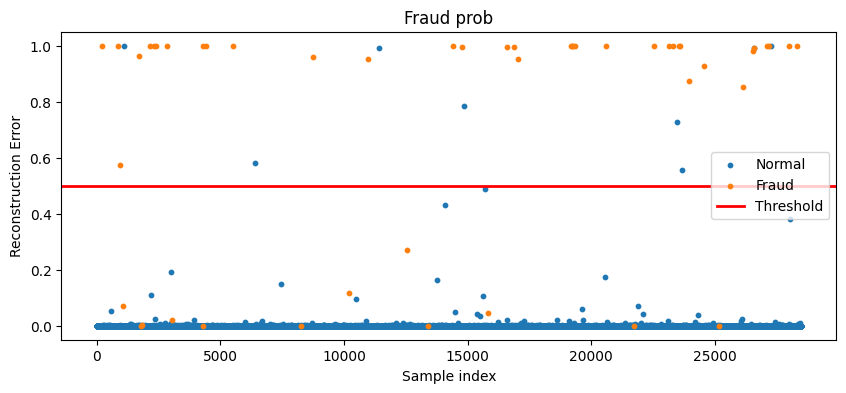

In [84]:
import pandas as pd

error_df = pd.DataFrame({
    "prob": probabilidades_AE,  # salida del AE
    "true_class": y_test  # 0/1
})

groups = error_df.groupby("true_class")
fig, ax = plt.subplots(figsize=(10,4))

# Graficamos los puntos
for name, group in groups:
    ax.scatter(
        group.index,
        group.prob,
        s = 10,
        label="Fraud" if name == 1 else "Normal"
    )

# Graficamos la frontera de decisión
ax.axhline(0.5, color='r', linewidth=2, label='Threshold')

ax.set_title("Fraud prob")
ax.set_xlabel("Sample index")
ax.set_ylabel("Reconstruction Error")
ax.legend()
plt.show()

In [85]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, prediccionesAE))

print("Matriz de Confusión:")
print(confusion_matrix(y_test, prediccionesAE))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28432
           1       0.82      0.76      0.79        49

    accuracy                           1.00     28481
   macro avg       0.91      0.88      0.89     28481
weighted avg       1.00      1.00      1.00     28481

Matriz de Confusión:
[[28424     8]
 [   12    37]]


In [89]:
tn, fp, fn, tp = confusion_matrix(y_test, prediccionesAE).ravel()

precision = tp / (tp + fp)
recall = tp / (tp + fn)
print("Precision:", precision)
print("Recall:", recall)

Precision: 0.8222222222222222
Recall: 0.7551020408163265


AUCPR: 0.8014690237742071


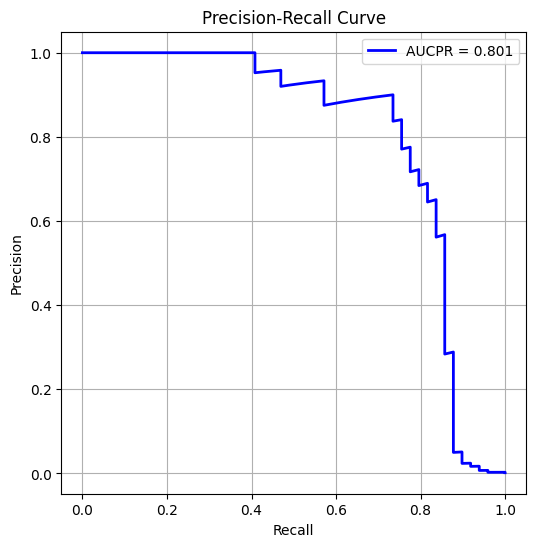

In [90]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, probabilidades_AE)
aucpr = average_precision_score(y_test, probabilidades_AE)
print("AUCPR:", aucpr)
plt.figure(figsize=(6,6))
plt.plot(recall, precision, color='b', lw=2, label=f'AUCPR = {aucpr:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()